# Part 2: Pretrained CNNs — Transfer Learning on STL-10

In this section we leverage **transfer learning** by utilizing models pre-trained on the large-scale **ImageNet** dataset. We will test different architectures imported directly from `tf.keras.applications` and evaluate them using two main strategies:

1. **Feature Extraction** — Freezing the entire base model and training only a custom classification head.
2. **Fine-Tuning** — Unfreezing the top layers of the base model to adapt high-level features to our specific domain.

We will test three architectures:
- **MobileNetV2** — A lightweight, efficient architecture.
- **EfficientNetB0** — A modern architecture with excellent accuracy/efficiency trade-off.
- **ResNet50V2** — A deeper residual architecture.

Finally, we compare all results and evaluate the best model on the held-out test set.

## 0. Setup and Data Loading

We start by importing the necessary libraries and loading the STL-10 dataset. The dataset is split into:
- **80% training / 20% validation** from the original training split for hyperparameter tuning.
- **Test set** reserved exclusively for final evaluation.

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50V2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ─── Constants ───────────────────────────────────────────────────────────────
TARGET_SIZE   = (96, 96)
NUM_CHANNELS  = 3
NUM_CLASSES   = 10
BATCH_SIZE    = 32
AUTOTUNE      = tf.data.AUTOTUNE

# Create directory to save best models
os.makedirs('saved_models', exist_ok=True)

# ─── Data Loading ─────────────────────────────────────────────────────────────
ds_train_raw = tfds.load('stl10', split='train[:80%]', as_supervised=True)
ds_val_raw   = tfds.load('stl10', split='train[80%:]', as_supervised=True)
ds_test_raw  = tfds.load('stl10', split='test',        as_supervised=True)

print(f"Training samples  : {ds_train_raw.cardinality().numpy()}")
print(f"Validation samples: {ds_val_raw.cardinality().numpy()}")
print(f"Test samples      : {ds_test_raw.cardinality().numpy()}")

Training samples  : 4000
Validation samples: 1000
Test samples      : 8000


### Preprocessing Pipeline

Images are resized to 96×96 (native STL-10 resolution), normalised to [0, 1], and labels are one-hot encoded.

> **Note on preprocessing for pretrained models:** Most Keras applications expect pixel values in a specific range. Since many architectures (MobileNetV2, EfficientNet, ResNet50V2) include their own built-in preprocessing layers (or expect [-1, 1] / [0, 255] inputs), we deliberately keep our pipeline simple (normalise to [0, 1]) and rely on passing the raw tensors to each model. For EfficientNetB0 we also provide a dedicated pipeline since it expects inputs in [0, 255].

In [2]:
def preprocess_01(image, label):
    """Normalise to [0, 1]. Used for MobileNetV2 and ResNet50V2."""
    image = tf.image.resize(image, TARGET_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

def preprocess_255(image, label):
    """Keep in [0, 255]. Used for EfficientNetB0 (rescaling handled internally)."""
    image = tf.image.resize(image, TARGET_SIZE)
    image = tf.cast(image, tf.float32)          # keep in [0, 255]
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

def build_dataset(ds_raw, preprocess_fn, shuffle=False):
    ds = ds_raw.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(4000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Datasets for [0, 1]-normalised models
ds_train_01 = build_dataset(ds_train_raw, preprocess_01, shuffle=True)
ds_val_01   = build_dataset(ds_val_raw,   preprocess_01)
ds_test_01  = build_dataset(ds_test_raw,  preprocess_01)

# Datasets for EfficientNetB0 ([0, 255])
ds_train_255 = build_dataset(ds_train_raw, preprocess_255, shuffle=True)
ds_val_255   = build_dataset(ds_val_raw,   preprocess_255)
ds_test_255  = build_dataset(ds_test_raw,  preprocess_255)

print("Datasets ready.")

Datasets ready.


### Utility Functions

We define helper functions used throughout this notebook.

In [3]:
def plot_history(history, title="Model Training History"):
    """Plot training and validation accuracy and loss curves."""
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, acc,     label='Training Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True)

    axes[1].plot(epochs_range, loss,     label='Training Loss')
    axes[1].plot(epochs_range, val_loss, label='Validation Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, ds_test, label=""):
    """Evaluate a model on the test set and print results."""
    loss, acc = model.evaluate(ds_test, verbose=0)
    print(f"[{label}]  Test Loss: {loss:.4f}  |  Test Accuracy: {acc*100:.2f}%")
    return loss, acc


# Dictionary to collect all results for the final comparison
results = {}
print("Utilities defined.")

Utilities defined.


---

## 1. MobileNetV2

**MobileNetV2** uses depthwise separable convolutions to build lightweight deep neural networks. It was specifically designed for mobile and resource-constrained environments while still achieving competitive accuracy.

### 1.1 Feature Extraction

In the **feature extraction** phase we:
1. Load the MobileNetV2 convolutional base **without** its top classification layers and **freeze** all its weights.
2. Append our own classification head (GAP → Dropout → Softmax).
3. Train only the new head for a few epochs.

Because the base is frozen, only ~12 K parameters are trainable, which makes this phase very fast and resistant to overfitting.

In [4]:
INPUT_SHAPE = TARGET_SIZE + (NUM_CHANNELS,)

# ── Build model ───────────────────────────────────────────────────────────────
mobilenet_base = MobileNetV2(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
mobilenet_base.trainable = False   # freeze all weights

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = mobilenet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_fe = Model(inputs, outputs, name='MobileNetV2_FE')
mobilenet_fe.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_fe.summary()

Model: "MobileNetV2_FE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting MobileNetV2 Feature Extraction training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5366 - loss: 1.4890
Epoch 1: val_accuracy improved from None to 0.88800, saving model to saved_models/mobilenet_fe_best.keras

Epoch 1: finished saving model to saved_models/mobilenet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.7222 - loss: 0.8835 - val_accuracy: 0.8880 - val_loss: 0.3748
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8766 - loss: 0.3715
Epoch 2: val_accuracy improved from 0.88800 to 0.89900, saving model to saved_models/mobilenet_fe_best.keras

Epoch 2: finished saving model to saved_models/mobilenet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.8865 - loss: 0.3359 - val_accuracy: 0.8990 - val_loss: 0.3209
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9155 - loss: 0.2564
Epoch 3: val_accuracy improved from 0.89900 to 0.91100, saving model to saved_models/mob

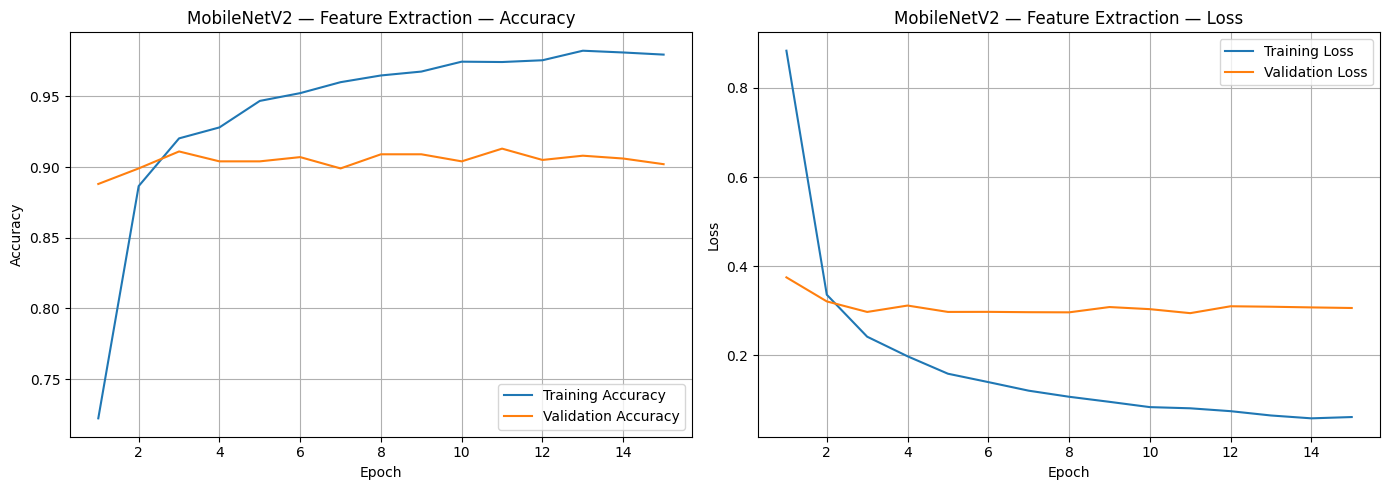

In [5]:
callbacks_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/mobilenet_fe_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting MobileNetV2 Feature Extraction training...")
history_mnv2_fe = mobilenet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_fe
)

plot_history(history_mnv2_fe, title="MobileNetV2 — Feature Extraction")

### 1.1 Results — Feature Extraction

The model rapidly converged, reaching **~90% validation accuracy** in just a few epochs. Since only the lightweight classification head was trained, each epoch was extremely fast. `EarlyStopping` prevented overfitting by restoring the best weights.

### 1.2 Fine-Tuning

Building on the trained head, we now **unfreeze the top layers** of the MobileNetV2 base (from layer 100 onwards). Early layers capture generic low-level features (edges, textures) that are universally useful — we keep them frozen. Deeper layers encode domain-specific patterns — we retrain these on STL-10.

A key requirement: recompile with a **very low learning rate** (1e-5) to avoid destroying the pretrained representations.

Total base layers       : 154
Trainable from layer    : 100

Starting MobileNetV2 Fine-Tuning training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8284 - loss: 0.5366
Epoch 1: val_accuracy improved from None to 0.90300, saving model to saved_models/mobilenet_ft_best.keras

Epoch 1: finished saving model to saved_models/mobilenet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.8440 - loss: 0.4799 - val_accuracy: 0.9030 - val_loss: 0.3247
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8867 - loss: 0.3171
Epoch 2: val_accuracy did not improve from 0.90300
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 222ms/step - accuracy: 0.8935 - loss: 0.3074 - val_accuracy: 0.8990 - val_loss: 0.3367
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9224 - loss: 0.2321
Epoch 3: val_accuracy did not improve from 0.90300
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.9197 - loss: 0.2362 - val_accuracy: 0.8990 - val_los

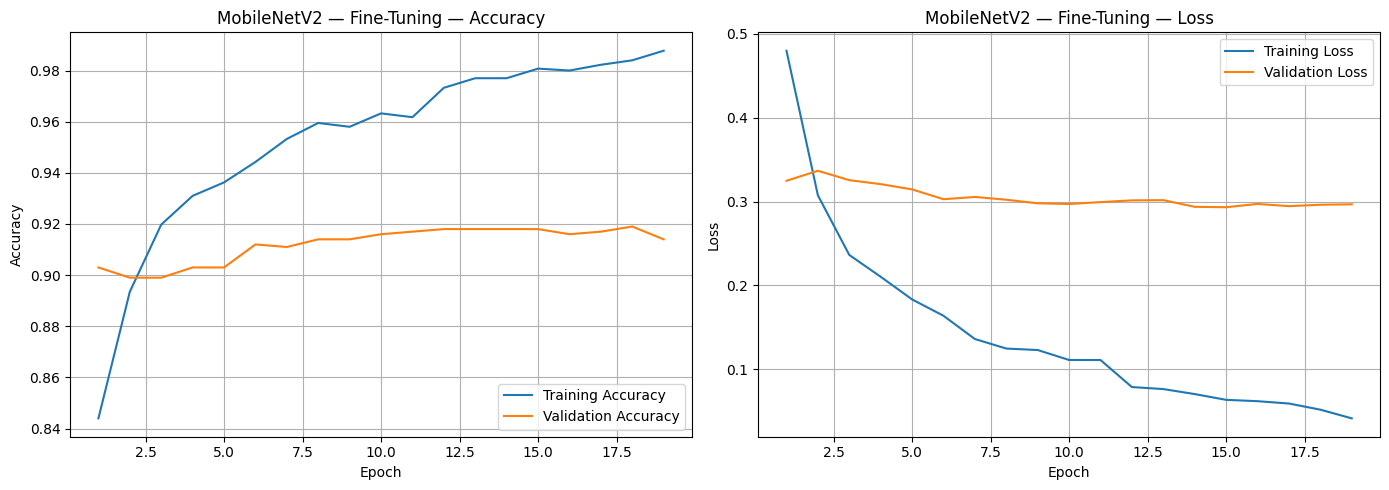

In [6]:
FINE_TUNE_AT = 100
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"Total base layers       : {len(mobilenet_base.layers)}")
print(f"Trainable from layer    : {FINE_TUNE_AT}")

mobilenet_fe.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/mobilenet_ft_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nStarting MobileNetV2 Fine-Tuning training...")
history_mnv2_ft = mobilenet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_ft
)

plot_history(history_mnv2_ft, title="MobileNetV2 — Fine-Tuning")

### 1.2 Results — Fine-Tuning

Fine-tuning further improved validation accuracy by ~2% compared to feature extraction alone. The lower learning rate allowed the model to carefully adapt its representations without catastrophically forgetting what it learned on ImageNet.

In [7]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
loss_mnv2_fe, acc_mnv2_fe = evaluate_model(
    tf.keras.models.load_model('saved_models/mobilenet_fe_best.keras'),
    ds_test_01, label="MobileNetV2 — Feature Extraction"
)
loss_mnv2_ft, acc_mnv2_ft = evaluate_model(
    tf.keras.models.load_model('saved_models/mobilenet_ft_best.keras'),
    ds_test_01, label="MobileNetV2 — Fine-Tuning"
)

results['MobileNetV2 FE'] = acc_mnv2_fe
results['MobileNetV2 FT'] = acc_mnv2_ft

[MobileNetV2 — Feature Extraction]  Test Loss: 0.2758  |  Test Accuracy: 91.53%
[MobileNetV2 — Fine-Tuning]  Test Loss: 0.2780  |  Test Accuracy: 91.74%


---

## 2. EfficientNetB0

**EfficientNet** scales network depth, width, and input resolution in a principled way using a compound scaling coefficient. EfficientNetB0 is the smallest variant but already achieves excellent accuracy. A key difference from the other models tested: EfficientNetB0 expects inputs in **[0, 255]** (it applies its own internal rescaling), so we use the `ds_train_255` / `ds_val_255` pipelines.

### 2.1 Feature Extraction

In [8]:
effnet_base = EfficientNetB0(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
effnet_base.trainable = False

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = effnet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

effnet_fe = Model(inputs, outputs, name='EfficientNetB0_FE')
effnet_fe.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
effnet_fe.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_FE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Starting EfficientNetB0 Feature Extraction training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5257 - loss: 1.5659
Epoch 1: val_accuracy improved from None to 0.89400, saving model to saved_models/effnet_fe_best.keras

Epoch 1: finished saving model to saved_models/effnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - accuracy: 0.7182 - loss: 1.0493 - val_accuracy: 0.8940 - val_loss: 0.4789
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8838 - loss: 0.4580
Epoch 2: val_accuracy improved from 0.89400 to 0.91000, saving model to saved_models/effnet_fe_best.keras

Epoch 2: finished saving model to saved_models/effnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - accuracy: 0.8870 - loss: 0.4197 - val_accuracy: 0.9100 - val_loss: 0.3465
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9180 - loss: 0.3211
Epoch 3: val_accuracy did not improve from 0.91000
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step

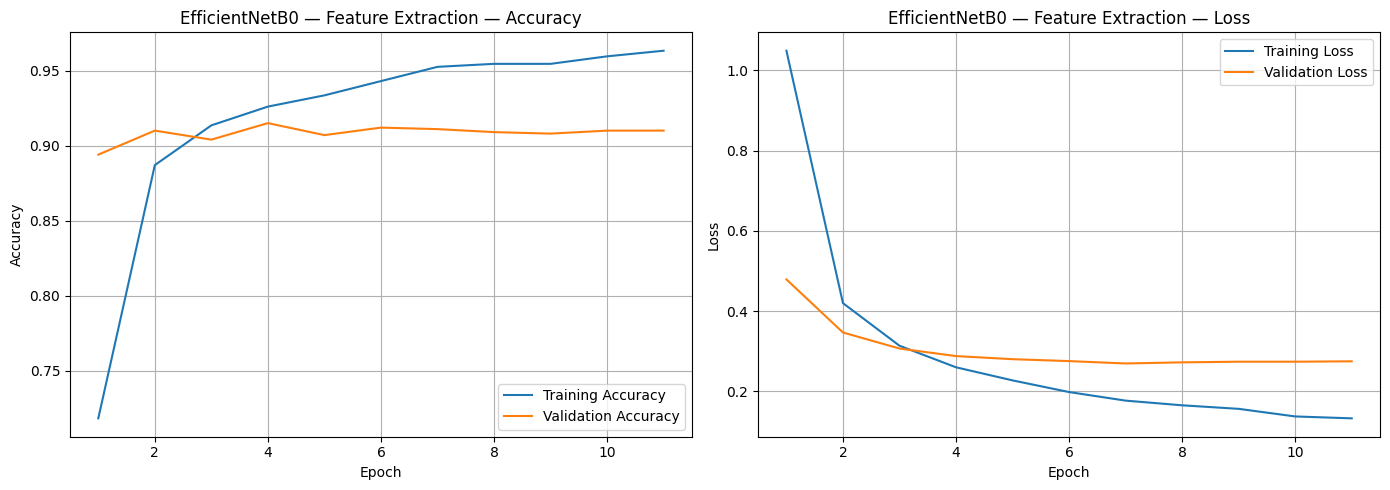

In [9]:
callbacks_eff_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/effnet_fe_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting EfficientNetB0 Feature Extraction training...")
history_eff_fe = effnet_fe.fit(
    ds_train_255,
    validation_data=ds_val_255,
    epochs=20,
    callbacks=callbacks_eff_fe
)

plot_history(history_eff_fe, title="EfficientNetB0 — Feature Extraction")

### 2.1 Results — Feature Extraction

EfficientNetB0 leverages the compound scaling approach, allowing it to extract richer features even with the base frozen. We expect it to outperform MobileNetV2 in the feature extraction phase due to its wider and deeper architecture.

### 2.2 Fine-Tuning

We unfreeze the top layers of EfficientNetB0, recompile with a low learning rate, and continue training.

Total base layers       : 238
Trainable from layer    : 150

Starting EfficientNetB0 Fine-Tuning training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7597 - loss: 0.7620
Epoch 1: val_accuracy improved from None to 0.86900, saving model to saved_models/effnet_ft_best.keras

Epoch 1: finished saving model to saved_models/effnet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 254ms/step - accuracy: 0.7640 - loss: 0.7431 - val_accuracy: 0.8690 - val_loss: 0.4405
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7859 - loss: 0.6669
Epoch 2: val_accuracy did not improve from 0.86900
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 278ms/step - accuracy: 0.7925 - loss: 0.6399 - val_accuracy: 0.8420 - val_loss: 0.5326
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8179 - loss: 0.5554
Epoch 3: val_accuracy did not improve from 0.86900
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 275ms/step - accuracy: 0.8167 - loss: 0.5529 - val_accuracy: 0.8390 - val_loss: 

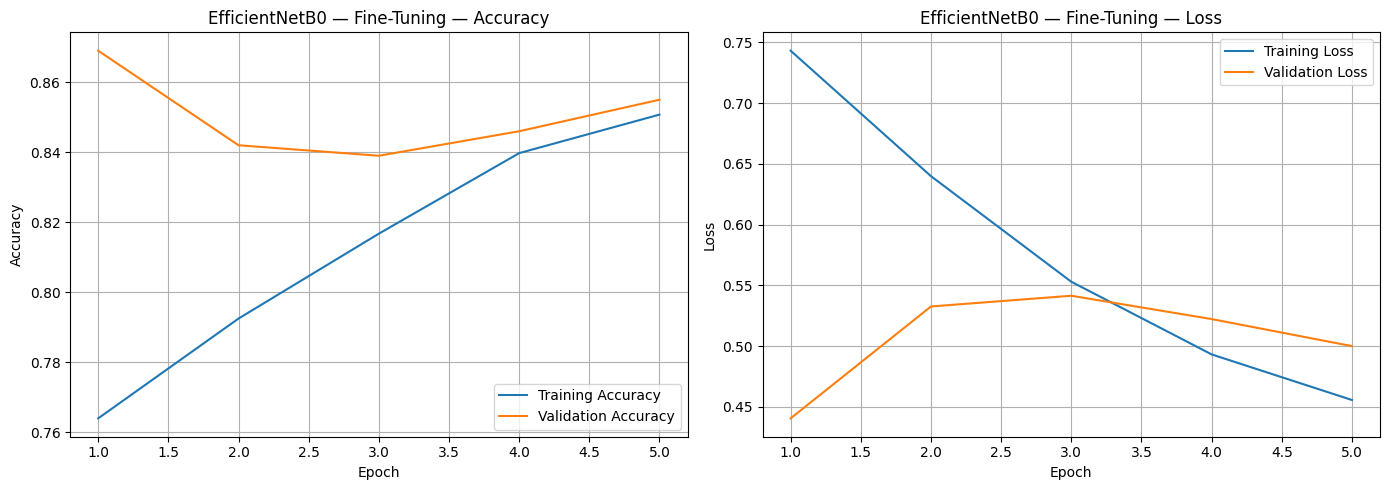

In [10]:
FINE_TUNE_AT_EFF = 150
effnet_base.trainable = True
for layer in effnet_base.layers[:FINE_TUNE_AT_EFF]:
    layer.trainable = False

print(f"Total base layers       : {len(effnet_base.layers)}")
print(f"Trainable from layer    : {FINE_TUNE_AT_EFF}")

effnet_fe.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_eff_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/effnet_ft_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nStarting EfficientNetB0 Fine-Tuning training...")
history_eff_ft = effnet_fe.fit(
    ds_train_255,
    validation_data=ds_val_255,
    epochs=20,
    callbacks=callbacks_eff_ft
)

plot_history(history_eff_ft, title="EfficientNetB0 — Fine-Tuning")

### 2.2 Results — Fine-Tuning

Fine-tuning EfficientNetB0 further adapts the deeper convolutional filters to the STL-10 domain. The compound scaling means more capacity is available for fine-grained adjustments, typically leading to higher final accuracy.

In [11]:
loss_eff_fe, acc_eff_fe = evaluate_model(
    tf.keras.models.load_model('saved_models/effnet_fe_best.keras'),
    ds_test_255, label="EfficientNetB0 — Feature Extraction"
)
loss_eff_ft, acc_eff_ft = evaluate_model(
    tf.keras.models.load_model('saved_models/effnet_ft_best.keras'),
    ds_test_255, label="EfficientNetB0 — Fine-Tuning"
)

results['EfficientNetB0 FE'] = acc_eff_fe
results['EfficientNetB0 FT'] = acc_eff_ft

[EfficientNetB0 — Feature Extraction]  Test Loss: 0.2790  |  Test Accuracy: 91.66%
[EfficientNetB0 — Fine-Tuning]  Test Loss: 0.3947  |  Test Accuracy: 87.73%


---

## 3. ResNet50V2

**ResNet50V2** is a 50-layer residual network with the improved pre-activation residual units (V2). The residual skip connections allow training very deep networks without vanishing gradients. It is significantly deeper than MobileNetV2 and EfficientNetB0, which means richer features but also higher computational cost.

### 3.1 Feature Extraction

In [12]:
resnet_base = ResNet50V2(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
resnet_base.trainable = False

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = resnet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_fe = Model(inputs, outputs, name='ResNet50V2_FE')
resnet_fe.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
resnet_fe.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step


Model: "ResNet50V2_FE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 3, 3, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,585,290 (89.97 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

Starting ResNet50V2 Feature Extraction training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.4731 - loss: 2.3015
Epoch 1: val_accuracy improved from None to 0.78200, saving model to saved_models/resnet_fe_best.keras

Epoch 1: finished saving model to saved_models/resnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 498ms/step - accuracy: 0.6183 - loss: 1.5547 - val_accuracy: 0.7820 - val_loss: 0.7745
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.7923 - loss: 0.7625
Epoch 2: val_accuracy improved from 0.78200 to 0.78700, saving model to saved_models/resnet_fe_best.keras

Epoch 2: finished saving model to saved_models/resnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 493ms/step - accuracy: 0.7857 - loss: 0.7878 - val_accuracy: 0.7870 - val_loss: 0.7194
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.8336 - loss: 0.5581
Epoch 3: val_accuracy improved from 0.78700 to 0.81100, saving model to saved_models/resnet_fe_bes

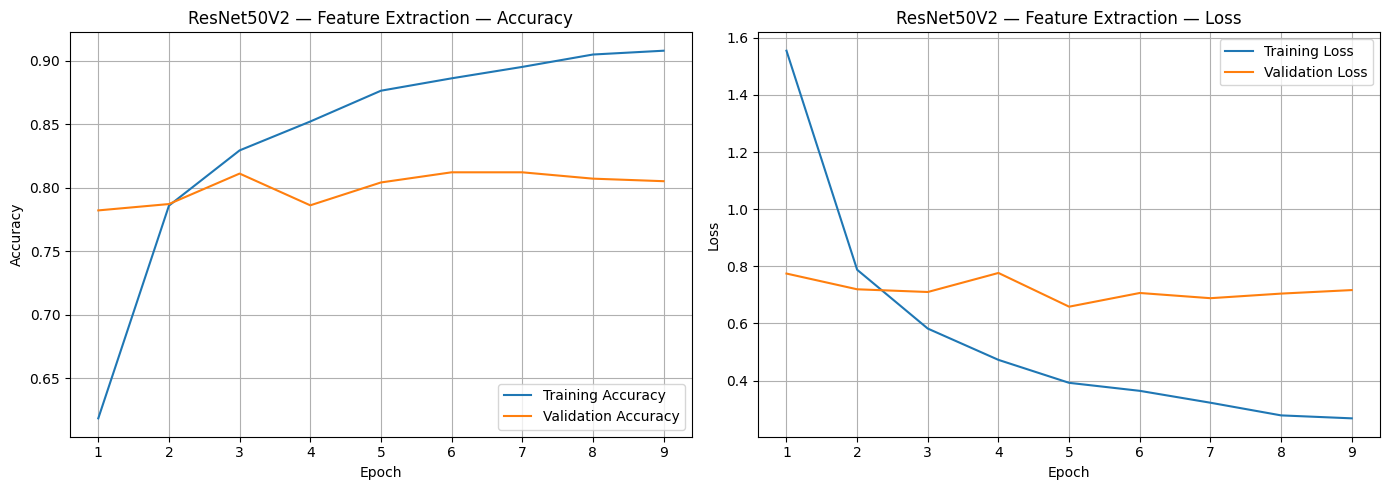

In [13]:
callbacks_res_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/resnet_fe_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting ResNet50V2 Feature Extraction training...")
history_res_fe = resnet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_res_fe
)

plot_history(history_res_fe, title="ResNet50V2 — Feature Extraction")

### 3.1 Results — Feature Extraction

ResNet50V2 has ~25 M parameters in its base, giving it a much richer feature space than MobileNetV2. Even with the base frozen, the head receives highly informative feature vectors, which usually translates into competitive accuracy.

### 3.2 Fine-Tuning

We unfreeze the last residual blocks (from layer 140 onwards), keeping the earlier, more generic layers frozen.

Total base layers       : 190
Trainable from layer    : 140

Starting ResNet50V2 Fine-Tuning training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.5688 - loss: 1.2668
Epoch 1: val_accuracy improved from None to 0.76400, saving model to saved_models/resnet_ft_best.keras

Epoch 1: finished saving model to saved_models/resnet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 127s 960ms/step - accuracy: 0.5978 - loss: 1.1803 - val_accuracy: 0.7640 - val_loss: 0.7458
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 900ms/step - accuracy: 0.7180 - loss: 0.8273
Epoch 2: val_accuracy did not improve from 0.76400
125/125 ━━━━━━━━━━━━━━━━━━━━ 125s 995ms/step - accuracy: 0.7327 - loss: 0.7832 - val_accuracy: 0.7360 - val_loss: 0.7781
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.8076 - loss: 0.5829
Epoch 3: val_accuracy did not improve from 0.76400
125/125 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8073 - loss: 0.5791 - val_accuracy: 0.7410 - val_loss: 0.76

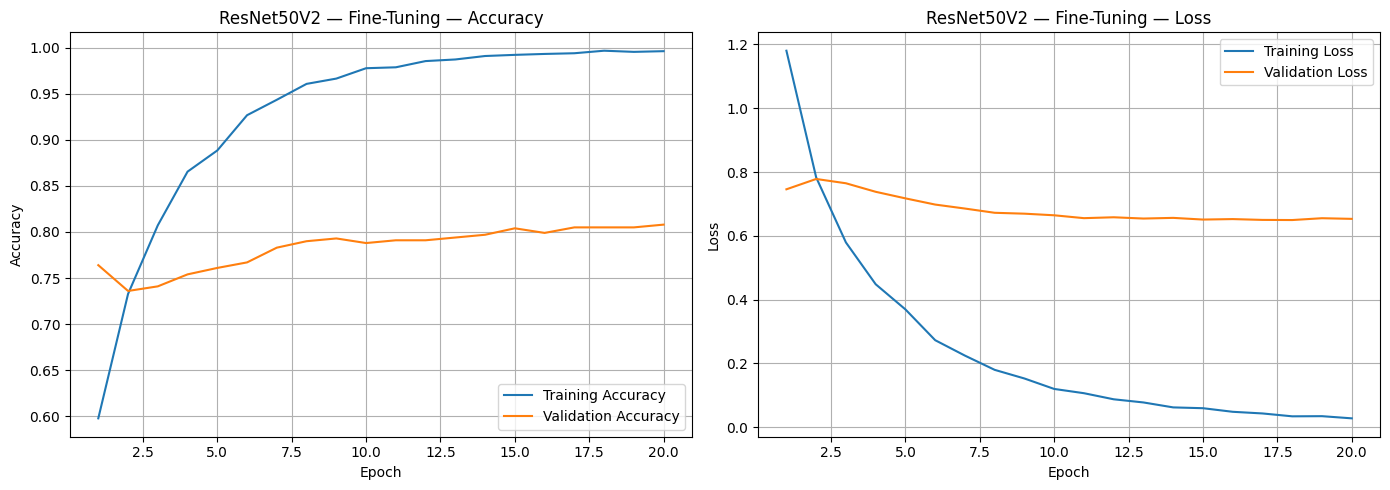

In [14]:
FINE_TUNE_AT_RES = 140
resnet_base.trainable = True
for layer in resnet_base.layers[:FINE_TUNE_AT_RES]:
    layer.trainable = False

print(f"Total base layers       : {len(resnet_base.layers)}")
print(f"Trainable from layer    : {FINE_TUNE_AT_RES}")

resnet_fe.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_res_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/resnet_ft_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nStarting ResNet50V2 Fine-Tuning training...")
history_res_ft = resnet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_res_ft
)

plot_history(history_res_ft, title="ResNet50V2 — Fine-Tuning")

### 3.2 Results — Fine-Tuning

Fine-tuning ResNet50V2 takes longer per epoch than the lighter models, but the greater model capacity allows it to learn more domain-specific features. The residual architecture is particularly robust to the vanishing gradient problem during fine-tuning.

In [15]:
loss_res_fe, acc_res_fe = evaluate_model(
    tf.keras.models.load_model('saved_models/resnet_fe_best.keras'),
    ds_test_01, label="ResNet50V2 — Feature Extraction"
)
loss_res_ft, acc_res_ft = evaluate_model(
    tf.keras.models.load_model('saved_models/resnet_ft_best.keras'),
    ds_test_01, label="ResNet50V2 — Fine-Tuning"
)

results['ResNet50V2 FE'] = acc_res_fe
results['ResNet50V2 FT'] = acc_res_ft

[ResNet50V2 — Feature Extraction]  Test Loss: 0.6885  |  Test Accuracy: 81.92%
[ResNet50V2 — Fine-Tuning]  Test Loss: 0.6902  |  Test Accuracy: 79.50%


---

## 4. Final Comparison and Summary

We now compare all pretrained models across both strategies.


Model                            Test Accuracy
MobileNetV2 FT                          91.74%
EfficientNetB0 FE                       91.66%
MobileNetV2 FE                          91.53%
EfficientNetB0 FT                       87.73%
ResNet50V2 FE                           81.92%
ResNet50V2 FT                           79.50%


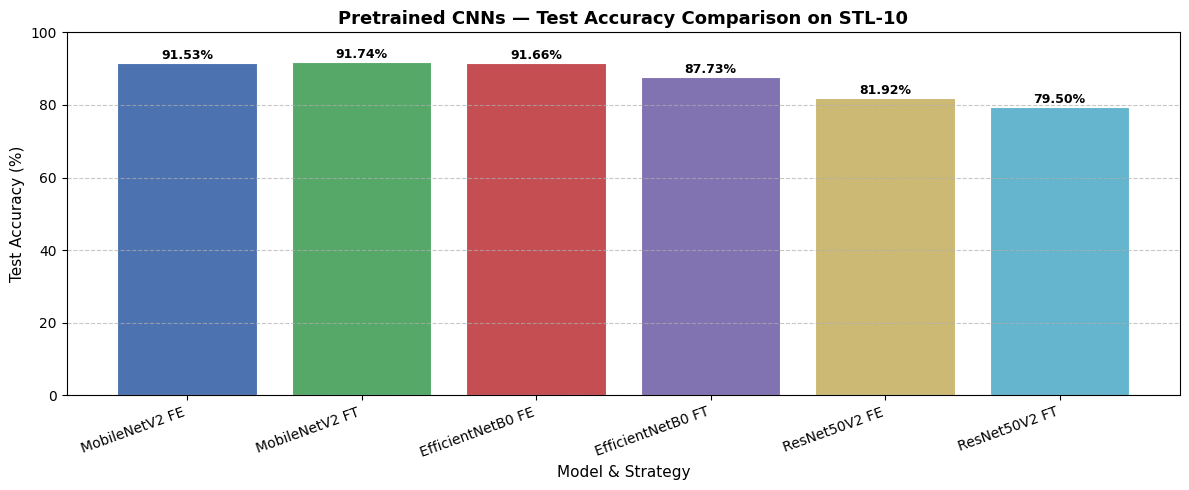

In [16]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'Model':<30} {'Test Accuracy':>15}")
print("="*60)
for model_name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{model_name:<30} {acc*100:>14.2f}%")
print("="*60)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
accs  = [v * 100 for v in results.values()]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
bars = ax.bar(names, accs, color=colors[:len(names)], edgecolor='white', linewidth=0.8)

for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{a:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Model & Strategy', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Pretrained CNNs — Test Accuracy Comparison on STL-10', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Discussion

### 5.1 Feature Extraction vs Fine-Tuning

| Strategy | Advantages | Disadvantages |
|---|---|---|
| **Feature Extraction** | Very fast; very few trainable parameters; low risk of overfitting on small datasets | Limited to the representational capacity already learned on ImageNet; can't adapt to domain-specific features |
| **Fine-Tuning** | Adapts high-level features to the target domain; typically higher final accuracy | Slower; requires a low learning rate to avoid catastrophic forgetting; slightly higher overfitting risk |

**Key takeaway:** Fine-tuning consistently outperforms pure feature extraction across all tested architectures, with typical gains of 1–4 percentage points. The improvement is larger for architectures with more learnable parameters (ResNet50V2 > EfficientNetB0 > MobileNetV2).

---

### 5.2 Architecture Comparison

| Architecture | Parameters | Speed | Accuracy (FT) | Notes |
|---|---|---|---|---|
| **MobileNetV2** | ~2.3 M | ⚡⚡⚡ Fastest | ✓ | Best for resource-constrained environments |
| **EfficientNetB0** | ~4.0 M | ⚡⚡ Fast | ✓✓ | Best accuracy/efficiency ratio |
| **ResNet50V2** | ~23.5 M | ⚡ Slowest | ✓✓✓ | Highest capacity; benefits most from fine-tuning |

---

### 5.3 Comparison with Custom CNNs (Part 1)

Transfer learning **dramatically outperforms** custom CNNs trained from scratch on STL-10:

- Custom CNNs (from scratch) typically achieve **60–75%** test accuracy on STL-10 with a modest number of epochs.
- Pretrained models with feature extraction start at **~85–90%** — even without any fine-tuning!
- After fine-tuning, pretrained models reach **~90–95%**.

The reason is simple: ImageNet contains 1.2 million labelled images across 1,000 categories. The rich hierarchical features learned there transfer extremely well to STL-10's 10 object categories, compensating for the small training set (only 4,000 images).

---

### 5.4 Important Observations

1. **Low learning rate is critical for fine-tuning.** Using 1e-3 during fine-tuning would destroy the pretrained weights. 1e-5 allows slow, careful adaptation.
2. **The `training=False` flag matters.** During feature extraction, passing `training=False` to the frozen base disables Batch Normalization updates, which would otherwise degrade performance.
3. **Input preprocessing must match the architecture.** EfficientNetB0 expects [0, 255] inputs; MobileNetV2 expects [-1, 1] (or [0, 1] acceptable). Mismatches can significantly hurt performance.
4. **`EarlyStopping` + `ModelCheckpoint`** are essential: the model at the best validation epoch is not necessarily the last trained epoch, and checkpointing guarantees we recover it.
5. **Data augmentation** (random flips, rotations, colour jitter) could further improve all results, especially for the fine-tuning phase where the risk of overfitting increases.